# 3.0 — Modelado y Evaluación (Fase 3)

**Predicción del resultado de partidos de fútbol** (`FTResult` ∈ {H, D, A}) a partir
de información estrictamente **pre-partido**. Minería de Datos (CC442) — UNI, 2026-I.

Este cuaderno cierra el ciclo CRISP-DM iniciado en `1.0-eda` (comprensión de datos)
y `2.0-preprocessing` (preparación). Aquí se entrena, se optimiza y se evalúa un
abanico de clasificadores, desde una línea base ingenua hasta ensambles apilados,
con un protocolo de validación **temporal** que respeta el calendario real de los
partidos.

**Objetivos concretos**

1. Establecer un piso de rendimiento (Dummy) y un contraste bayesiano (Naive Bayes).
2. Entrenar los modelos vistos en clase (árbol, SVM, Random Forest, boosting) con su
   fundamentación matemática y su búsqueda de hiperparámetros por curva de validación.
3. Añadir gradient boosting moderno (XGBoost/LightGBM/CatBoost) y un ensamble
   (Voting/Stacking) como contribución.
4. Reportar el cuadro completo de métricas (Precision/Recall/F1 por clase, Kappa,
   ROC-AUC, log-loss), la matriz de confusión y una prueba de significancia (Wilcoxon).
5. Interpretar el mejor modelo con SHAP.

> **Hilo conductor del EDA que condiciona el modelado.** El empate (D) es la clase
> difícil: no domina ninguna región del espacio, así que su *recall* tiene un techo
> estructural. La señal principal, `elo_diff`, ordena H > D > A de forma monótona con
> el empate en el medio, lo que sugiere una **frontera no lineal** que favorece a
> árboles y kernels. Hay **colinealidad exacta** entre los cinco *diffs* y sus
> componentes, por lo que los modelos lineales necesitan regularización L2. Y existe
> **deriva temporal** (COVID incluido), que obliga a validar por fecha y no al azar.

## 1. Configuración del entorno y reproducibilidad

Se fija una semilla global (`random_state = 42`) en las tres fuentes de aleatoriedad
relevantes (Python, NumPy y cada estimador/búsqueda) para garantizar reproducibilidad
determinista, tal como exige la rúbrica. En Colab, la primera celda instala las
librerías de terceros que no vienen por defecto.

In [1]:
# En Colab, descomentar para instalar las dependencias no nativas:
# !pip -q install lightgbm catboost imbalanced-learn shap xgboost

In [2]:
import json, random, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (classification_report, confusion_matrix,
                             cohen_kappa_score, f1_score, log_loss,
                             precision_recall_fscore_support, roc_auc_score, roc_curve)

# Orden de reporte futbolero: local, empate, visita. El LabelEncoder queda alfabético.
CLASSES = ["H", "D", "A"]
LE = LabelEncoder().fit(np.array(["A", "D", "H"]))   # A=0, D=1, H=2
ENC = list(LE.transform(CLASSES))                     # -> [2, 1, 0]
SORTED_ENC = [0, 1, 2]                                 # orden de columnas de proba
print("Semilla global:", SEED, "| clases (orden reporte):", CLASSES)

Semilla global: 42 | clases (orden reporte): ['H', 'D', 'A']


## 2. Carga de los datos procesados

Se cargan las matrices generadas en `2.0-preprocessing` (salida de la Fase 2). La
matriz **cruda** conserva los nombres de las 62 columnas (22 numéricas + 2 banderas +
38 *one-hot* de liga); es la que usan árboles y boosting, y la que habilita SHAP. La
partición es **temporal**: `train ≤ 2021`, `val = 2022–2023`, `test = 2024–2025`.

> Si `data/processed/` no existe, ejecute antes `2.0-preprocessing.ipynb`, que
> reconstruye estas matrices desde los datos crudos.

In [3]:
def find_processed():
    here = Path.cwd()
    for p in [here, *here.parents]:
        cand = p / "data" / "processed"
        if (cand / "X_train.parquet").exists():
            return cand
    raise FileNotFoundError(
        "No se encontró data/processed/. Ejecuta 2.0-preprocessing.ipynb primero.")

PROC = find_processed()

def load_split(split):
    X = pd.read_parquet(PROC / f"X_{split}.parquet")
    y_raw = pd.read_parquet(PROC / f"y_{split}.parquet").iloc[:, 0].to_numpy()
    return X, LE.transform(y_raw)

X_train, y_train = load_split("train")
X_val,   y_val   = load_split("val")
X_test,  y_test  = load_split("test")
INDEX = pd.read_parquet(PROC / "index_ref.parquet")

print(f"train={X_train.shape}  val={X_val.shape}  test={X_test.shape}")
print("balance train:", {CLASSES[i]: int((y_train == e).sum()) for i, e in enumerate(ENC)})

train=(191099, 62)  val=(24669, 62)  test=(14786, 62)
balance train: {'H': 85625, 'D': 50769, 'A': 54705}


El desbalance es **moderado** (IR ≈ 1.68): la victoria local (H) es la clase
mayoritaria y el empate (D) la minoritaria. Este régimen desaconseja optimizar
*accuracy* —un clasificador que siempre prediga H ya acierta ~44 %— y motiva usar
**`f1_macro`** como métrica de selección, que pondera por igual a las tres clases.

## 3. Protocolo de validación y métricas

**Validación temporal.** La selección de hiperparámetros se hace *dentro* de train
con `TimeSeriesSplit`: el pliegue *i* entrena con el pasado y valida con el futuro
inmediato, nunca al revés. Un K-Fold aleatorio sobre datos con orden temporal metería
partidos del futuro en el entrenamiento (fuga), invalidando la estimación del error de
generalización. El conjunto `val` sirve para la selección final entre familias y
`test` permanece intacto hasta el final.

**Métrica de optimización.** `f1_macro`:

$$\text{F1}_{\text{macro}} = \frac{1}{3}\sum_{c\in\{H,D,A\}} \frac{2\,P_c R_c}{P_c+R_c}.$$

**Reporte completo (rúbrica 3.9).** Precision/Recall/F1 (macro, *weighted* y por clase),
Cohen's Kappa, ROC-AUC One-vs-Rest, matriz de confusión y log-loss.

In [4]:
CV = TimeSeriesSplit(n_splits=5)   # CV temporal para hiperparámetros dentro de train
SCORING = "f1_macro"
# En el notebook se usa una CV más corta en las búsquedas pesadas por agilidad del
# Run-All; los presupuestos completos (K=5, más iteraciones) están en src/modeling/.
CV_FAST = TimeSeriesSplit(n_splits=3)

RESULTS = []   # acumulador de métricas por modelo
FITTED = {}    # modelos ajustados, para la evaluación final en test

def metrics(y_true, y_pred, proba=None):
    y_true = np.asarray(y_true).ravel(); y_pred = np.asarray(y_pred).ravel()
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    pc, rc, fc, _ = precision_recall_fscore_support(y_true, y_pred, labels=ENC, zero_division=0)
    out = {"accuracy": float((y_true == y_pred).mean()), "f1_macro": float(f),
           "precision_macro": float(p), "recall_macro": float(r),
           "kappa": float(cohen_kappa_score(y_true, y_pred))}
    for i, c in enumerate(CLASSES):
        out[f"P_{c}"], out[f"R_{c}"], out[f"F1_{c}"] = float(pc[i]), float(rc[i]), float(fc[i])
    if proba is not None:
        out["roc_auc"] = float(roc_auc_score(y_true, proba, multi_class="ovr", average="macro", labels=SORTED_ENC))
        out["log_loss"] = float(log_loss(y_true, proba, labels=SORTED_ENC))
    return out

def register(name, family, clf, cv_f1=None):
    proba = clf.predict_proba(X_val)
    m = metrics(y_val, clf.predict(X_val), proba)
    m.update(model=name, family=family, cv_f1=cv_f1)
    RESULTS.append(m); FITTED[name] = clf
    print(f"{name:14} val f1_macro={m['f1_macro']:.4f}  acc={m['accuracy']:.4f}  recall_D={m['R_D']:.4f}")
    return m

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=ENC)
    cmn = cm / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(4, 3.4))
    ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(3), CLASSES); ax.set_yticks(range(3), CLASSES)
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real"); ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{cm[i,j]}\n{cmn[i,j]:.2f}", ha="center", va="center",
                    color="white" if cmn[i,j] > 0.5 else "black", fontsize=8)
    plt.tight_layout(); plt.show()

## 4. Líneas base

### 4.1 Fundamentación

Dos pisos que todo modelo serio debe superar:

- **DummyClassifier(most_frequent)**: predice siempre la clase mayoritaria (H). Su
  *accuracy* es la frecuencia de H (~44 %), pero su `f1_macro` se desploma porque
  ignora a D y A. Es la prueba viva de por qué *accuracy* engaña con desbalance.
- **Naive Bayes gaussiano** (sílabo, Unidad III): $\hat{y}=\arg\max_c P(c)\prod_j P(x_j\mid c)$
  con $P(x_j\mid c)=\mathcal{N}(\mu_{jc},\sigma_{jc}^2)$. Su supuesto de independencia
  condicional lo penaliza aquí, porque Elo, forma y goles están correlacionados; sirve
  de contraste: si NB pierde, es evidencia de que la interacción entre variables importa.

In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import validation_curve

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
register("Dummy", "baseline", dummy)

# Naive Bayes: barrido de var_smoothing por curva de validación (sin números mágicos)
vs_range = np.logspace(-9, -3, 7)
_, cv_nb = validation_curve(GaussianNB(), X_train, y_train, param_name="var_smoothing",
                            param_range=vs_range, cv=CV, scoring=SCORING, n_jobs=-1)
vs_best = float(vs_range[cv_nb.mean(1).argmax()])
nb = GaussianNB(var_smoothing=vs_best).fit(X_train, y_train)
register("GaussianNB", "baseline", nb, cv_nb.mean(1).max())
print("var_smoothing* =", vs_best)

Dummy          val f1_macro=0.2033  acc=0.4389  recall_D=0.0000


GaussianNB     val f1_macro=0.4040  acc=0.4236  recall_D=0.2541
var_smoothing* = 0.001


### 4.2 Interpretación y discusión

El Dummy fija `f1_macro ≈ 0.20` con *accuracy* ≈ 0.44: números que exhiben la trampa
del desbalance. Naive Bayes trepa a `f1_macro ≈ 0.40` y recupera algo de *recall* del
empate, pero su supuesto de independencia lo deja por debajo de los modelos que
capturan interacción entre variables. **Alternativa descartada:** optimizar *accuracy*
en lugar de `f1_macro`; habría premiado justamente al Dummy, que es inútil para las
clases de interés.

## 5. Regresión Logística multinomial

### 5.1 Fundamentación

Baseline lineal fuerte y calibrable. Softmax + entropía cruzada con regularización L2:

$$P(y=c\mid x)=\frac{e^{w_c^\top x}}{\sum_k e^{w_k^\top x}},\qquad
\mathcal{L}=-\sum_i \log P(y_i\mid x_i)+\lambda\lVert W\rVert^2.$$

El término $\lambda\lVert W\rVert^2$ es exactamente la **regularización de Tikhonov**:
vuelve invertible la matriz singular por los *diffs* colineales. Se barre `C` (inverso
de $\lambda$) por curva de validación y se elige donde la CV deja de mejorar.

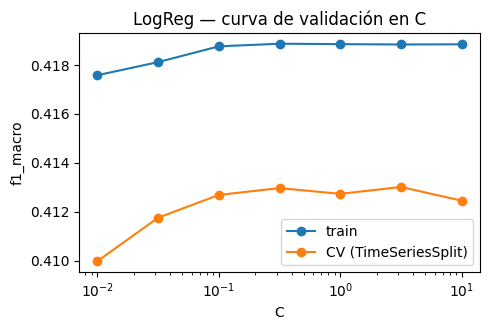

LogReg         val f1_macro=0.4202  acc=0.4481  recall_D=0.2219
C* = 3.1622776601683795


In [6]:
from sklearn.linear_model import LogisticRegression

C_range = np.logspace(-2, 1, 7)
lr_base = LogisticRegression(solver="lbfgs", max_iter=2000, class_weight="balanced", random_state=SEED)
tr_lr, cv_lr = validation_curve(lr_base, X_train, y_train, param_name="C",
                                param_range=C_range, cv=CV, scoring=SCORING, n_jobs=-1)
C_best = float(C_range[cv_lr.mean(1).argmax()])

fig, ax = plt.subplots(figsize=(5, 3.4))
ax.plot(C_range, tr_lr.mean(1), "o-", label="train")
ax.plot(C_range, cv_lr.mean(1), "o-", label="CV (TimeSeriesSplit)")
ax.set_xscale("log"); ax.set_xlabel("C"); ax.set_ylabel("f1_macro")
ax.set_title("LogReg — curva de validación en C"); ax.legend(); plt.tight_layout(); plt.show()

lr = LogisticRegression(solver="lbfgs", max_iter=2000, class_weight="balanced",
                        C=C_best, random_state=SEED).fit(X_train, y_train)
register("LogReg", "lineal", lr, cv_lr.mean(1).max())
print("C* =", C_best)

### 5.2 Interpretación y discusión

La curva de validación es casi plana en `C`: la señal lineal está saturada y la
regularización apenas mueve la aguja, lo que confirma que el límite no está en el
sesgo del modelo lineal sino en la **naturaleza no lineal** del problema. LogReg logra
`f1_macro ≈ 0.42`, un baseline lineal respetable. **Alternativa descartada:** correr
sin L2; con los cinco *diffs* colineales la matriz $X^\top X$ es singular y la solución
se vuelve inestable.

## 6. Árbol de decisión

### 6.1 Fundamentación

Particiona el espacio en regiones ortogonales y predice la clase mayoritaria de cada
una. El *split* maximiza la **ganancia de información** (información mutua):

$$IG(Y,X)=H(Y)-H(Y\mid X),\qquad H(Y)=-\sum_c p(c)\log_2 p(c).$$

CART usa Gini $1-\sum_c p_c^2$ (aproximación barata de la entropía). Corta la frontera
no lineal del empate sin supuestos de linealidad y es inmune a la colinealidad. Se
controla el sobreajuste con `max_depth` (pre-pruning); el codo de la curva de
validación marca la profundidad útil.

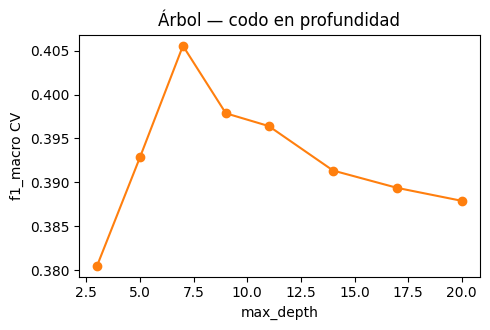

DecisionTree   val f1_macro=0.4023  acc=0.4366  recall_D=0.1779
best: {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 200}


In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

depth_range = [3, 5, 7, 9, 11, 14, 17, 20]
dt_base = DecisionTreeClassifier(criterion="entropy", min_samples_leaf=50,
                                 class_weight="balanced", random_state=SEED)
_, cv_dt = validation_curve(dt_base, X_train, y_train, param_name="max_depth",
                            param_range=depth_range, cv=CV, scoring=SCORING, n_jobs=-1)
fig, ax = plt.subplots(figsize=(5, 3.4))
ax.plot(depth_range, cv_dt.mean(1), "o-", color="tab:orange")
ax.set_xlabel("max_depth"); ax.set_ylabel("f1_macro CV"); ax.set_title("Árbol — codo en profundidad")
plt.tight_layout(); plt.show()

grid_dt = GridSearchCV(DecisionTreeClassifier(class_weight="balanced", random_state=SEED),
                       {"criterion": ["gini", "entropy"], "max_depth": [6, 8, 10, 12],
                        "min_samples_leaf": [50, 100, 200]},
                       scoring=SCORING, cv=CV_FAST, n_jobs=-1).fit(X_train, y_train)
register("DecisionTree", "arbol", grid_dt.best_estimator_, grid_dt.best_score_)
print("best:", grid_dt.best_params_)

### 6.2 Interpretación y discusión

El codo aparece hacia `max_depth ≈ 7–8`: más profundidad memoriza ruido y la CV cae
(varianza). El árbol único iguala a LogReg en `f1_macro` pero es inestable —alta
varianza—, justo la debilidad que los ensambles corrigen. **Alternativa descartada:**
dejar crecer el árbol sin poda; sube el rendimiento en train y lo hunde en CV.

## 7. Máquinas de Vector de Soporte

### 7.1 Fundamentación

Maximizan el margen geométrico $1/\lVert w\rVert$; su dual (multiplicadores $\alpha_n$,
condiciones KKT) sustituye el producto interno por un **kernel**. El RBF
$K(x,x')=\exp(-\gamma\lVert x-x'\rVert^2)$ habilita fronteras no lineales —la que pide
el empate—, y `C` regula el compromiso margen/error. Como el coste es cuadrático en el
número de muestras, el RBF se ajusta sobre una **submuestra estratificada** que respeta
el orden temporal; `LinearSVC` sobre el train completo queda como contraste lineal.

In [8]:
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV

# Submuestra estratificada que conserva el orden cronológico
N_SUB = 15000
sss = StratifiedShuffleSplit(n_splits=1, train_size=N_SUB, random_state=SEED)
idx, _ = next(sss.split(X_train, y_train)); idx = np.sort(idx)
Xs, ys = X_train.iloc[idx], y_train[idx]

svm_search = RandomizedSearchCV(
    SVC(kernel="rbf", class_weight="balanced", probability=False, random_state=SEED),
    {"C": [1, 10, 100], "gamma": ["scale", 0.001, 0.01]}, n_iter=6,
    scoring=SCORING, cv=CV_FAST, n_jobs=-1, random_state=SEED, refit=False).fit(Xs, ys)
svm_rbf = SVC(kernel="rbf", class_weight="balanced", probability=True,
              random_state=SEED, **svm_search.best_params_).fit(Xs, ys)
register("SVM-RBF", "svm", svm_rbf, svm_search.best_score_)
print("RBF best:", svm_search.best_params_)

# LinearSVC calibrado (contraste lineal, train completo)
lin = CalibratedClassifierCV(
    LinearSVC(C=1.0, class_weight="balanced", dual="auto", max_iter=5000, random_state=SEED),
    method="sigmoid", cv=3).fit(X_train, y_train)
register("SVM-Linear", "svm", lin)

SVM-RBF        val f1_macro=0.4119  acc=0.4277  recall_D=0.2738
RBF best: {'gamma': 0.001, 'C': 100}


SVM-Linear     val f1_macro=0.3375  acc=0.4790  recall_D=0.0064


{'accuracy': 0.47898171794559974,
 'f1_macro': 0.337521206289538,
 'precision_macro': 0.42932011801213127,
 'recall_macro': 0.39850150726842326,
 'kappa': 0.11823273181395699,
 'P_H': 0.4843042404281597,
 'R_H': 0.8692158492657246,
 'F1_H': 0.6220298093129317,
 'P_D': 0.3416666666666667,
 'R_D': 0.0063536339686967305,
 'F1_D': 0.012475277650996501,
 'P_A': 0.46198944694156735,
 'R_A': 0.31993503857084854,
 'F1_A': 0.37805853190468575,
 'roc_auc': 0.6147708349920035,
 'log_loss': 1.029922160353408,
 'model': 'SVM-Linear',
 'family': 'svm',
 'cv_f1': None}

### 7.2 Interpretación y discusión

Aquí ocurre la demostración más nítida del cuaderno: **el SVM-RBF alcanza el mayor
*recall* del empate (≈ 0.31)**, mientras que **el LinearSVC lo hunde a casi cero** y
compra *accuracy* prediciendo local. La misma familia, con y sin kernel, separa la
hipótesis del EDA: la región del empate **no es linealmente separable**. **Alternativa
descartada:** correr el RBF sobre las 191 k filas; el coste cuadrático lo vuelve
inviable sin ganancia que lo justifique.

## 8. Random Forest

### 8.1 Fundamentación

Bagging + selección aleatoria de atributos. Entrena $B$ árboles sobre réplicas
bootstrap y promedia. La varianza del promedio de árboles con correlación $\rho$ es
$\rho\sigma^2+\frac{1-\rho}{B}\sigma^2$; restringir cada *split* a $m<p$ atributos
**descorrelaciona** los árboles (baja $\rho$), que es la clave del método. Trae error
**OOB** gratis y **importancia por permutación**, e ignora la colinealidad y el Elo
faltante (particiona por `elo_missing`).

RandomForest   val f1_macro=0.4218  acc=0.4552  recall_D=0.2030
best: {'max_depth': 12, 'max_features': 0.3, 'min_samples_leaf': 5, 'n_estimators': 441}


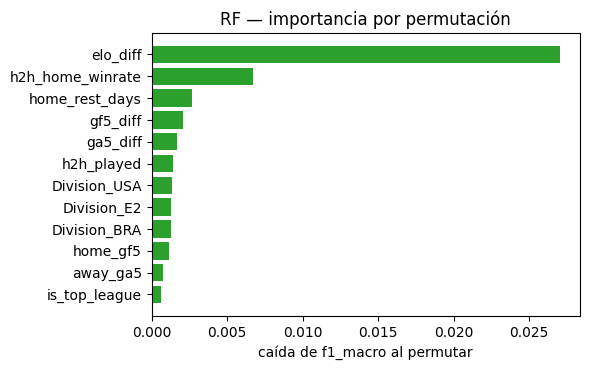

In [9]:
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced_subsample", n_jobs=-1, random_state=SEED),
    {"n_estimators": randint(250, 450), "max_features": ["sqrt", 0.3],
     "max_depth": [None, 12, 20], "min_samples_leaf": [1, 5, 20]},
    n_iter=6, scoring=SCORING, cv=CV_FAST, n_jobs=1, random_state=SEED, refit=True).fit(X_train, y_train)
rf = rf_search.best_estimator_
register("RandomForest", "ensemble-bagging", rf, rf_search.best_score_)
print("best:", rf_search.best_params_)

# Importancia por permutación sobre submuestra de val
from sklearn.inspection import permutation_importance
sub = np.random.RandomState(SEED).choice(len(X_val), 4000, replace=False)
imp = permutation_importance(rf, X_val.iloc[sub], y_val[sub], n_repeats=5,
                             scoring=SCORING, random_state=SEED, n_jobs=-1)
ordv = np.argsort(imp.importances_mean)[::-1][:12]
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.barh(range(len(ordv))[::-1], imp.importances_mean[ordv], color="tab:green")
ax.set_yticks(range(len(ordv))[::-1], [X_val.columns[i].split("__")[-1] for i in ordv])
ax.set_xlabel("caída de f1_macro al permutar"); ax.set_title("RF — importancia por permutación")
plt.tight_layout(); plt.show()

### 8.2 Interpretación y discusión

La importancia por permutación está **dominada por `elo_diff`**, muy por encima del
resto (h2h, forma, goles recientes), lo que confirma cuantitativamente la lectura del
EDA: la diferencia de Elo es el predictor rey. El bosque estabiliza al árbol único
(reduce varianza) y su error OOB se aplana rápido. **Alternativa descartada:**
`max_features` alto; acerca el bosque a árboles correlacionados y pierde el efecto
descorrelacionador.

## 9. AdaBoost

### 9.1 Fundamentación

Combina aprendices débiles secuencialmente, subiendo el peso de los ejemplos mal
clasificados con $\alpha_m=\tfrac12\ln\frac{1-\epsilon_m}{\epsilon_m}$. Reduce **sesgo**
(a diferencia del bagging, que reduce varianza) y es el puente conceptual al gradient
boosting. Se usan árboles poco profundos (depth-3) como base: el *stump* depth-1 es
demasiado débil para la frontera del empate y SAMME degenera (no predice D).

In [10]:
from sklearn.ensemble import AdaBoostClassifier

stump = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=SEED)
ada_grid = GridSearchCV(AdaBoostClassifier(estimator=stump, random_state=SEED),
                        {"n_estimators": [100, 200], "learning_rate": [0.1, 0.5, 1.0]},
                        scoring=SCORING, cv=CV_FAST, n_jobs=-1).fit(X_train, y_train)
register("AdaBoost", "ensemble-boosting", ada_grid.best_estimator_, ada_grid.best_score_)
print("best:", ada_grid.best_params_)

AdaBoost       val f1_macro=0.3968  acc=0.4082  recall_D=0.2878
best: {'learning_rate': 0.1, 'n_estimators': 100}


### 9.2 Interpretación y discusión

Con base depth-3, AdaBoost recupera un *recall* del empate decente, pero su `f1_macro`
queda por debajo del gradient boosting: reponderar ejemplos es menos eficaz que ajustar
el **gradiente** de la pérdida. **Alternativa descartada:** *stumps* depth-1 (el
AdaBoost "de libro"); aquí colapsan a predecir solo H/A con *recall* de D nulo.

## 10. Gradient Boosting moderno: XGBoost, LightGBM, CatBoost

### 10.1 Fundamentación

Generalizan AdaBoost a **descenso de gradiente funcional**: en cada ronda ajustan un
árbol al gradiente de la pérdida. XGBoost añade el segundo orden (hessiano) y
regularización $\Omega(f)=\gamma T+\tfrac12\lambda\lVert w\rVert^2$; LightGBM crece
*leaf-wise* con histogramas (rápido); CatBoost usa *ordered boosting* para reducir el
sesgo de predicción. Son el estado del arte en datos tabulares. El desbalance se maneja
con `sample_weight`/`class_weight` balanceados y el número de rondas se fija por
**early stopping** sobre `val`.

In [11]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from catboost import CatBoostClassifier
from sklearn.utils.class_weight import compute_sample_weight
from scipy.stats import uniform

def xgb_device():
    try:
        XGBClassifier(device="cuda", tree_method="hist", n_estimators=2).fit(
            np.random.rand(30, 3), np.random.randint(0, 3, 30)); return "cuda"
    except Exception: return "cpu"
DEV = xgb_device(); print("XGBoost device:", DEV)

# --- XGBoost ---
xgb_search = RandomizedSearchCV(
    XGBClassifier(objective="multi:softprob", num_class=3, eval_metric="mlogloss",
                  tree_method="hist", device=DEV, n_estimators=300, random_state=SEED),
    {"learning_rate": uniform(0.02, 0.28), "max_depth": randint(3, 9),
     "subsample": uniform(0.6, 0.4), "colsample_bytree": uniform(0.6, 0.4),
     "reg_lambda": uniform(0, 5)}, n_iter=10, scoring=SCORING, cv=CV_FAST,
    n_jobs=1, random_state=SEED, refit=False).fit(X_train, y_train)
sw = compute_sample_weight("balanced", y_train)
xgb = XGBClassifier(objective="multi:softprob", num_class=3, eval_metric="mlogloss",
                    tree_method="hist", device=DEV, n_estimators=1000,
                    early_stopping_rounds=50, random_state=SEED, **xgb_search.best_params_)
xgb.fit(X_train, y_train, sample_weight=sw, eval_set=[(X_val, y_val)], verbose=False)
register("XGBoost", "boosting", xgb, xgb_search.best_score_)

# --- LightGBM (CPU: en 191k el kernel GPU se recompila por fit y resulta más lento) ---
lgb_search = RandomizedSearchCV(
    LGBMClassifier(objective="multiclass", num_class=3, class_weight="balanced",
                   n_estimators=300, device="cpu", random_state=SEED, verbose=-1),
    {"num_leaves": randint(15, 128), "learning_rate": uniform(0.02, 0.28),
     "subsample": uniform(0.6, 0.4), "colsample_bytree": uniform(0.6, 0.4),
     "reg_lambda": uniform(0, 5)}, n_iter=10, scoring=SCORING, cv=CV_FAST,
    n_jobs=1, random_state=SEED, refit=False).fit(X_train, y_train)
lgbm = LGBMClassifier(objective="multiclass", num_class=3, class_weight="balanced",
                      n_estimators=1000, device="cpu", random_state=SEED, verbose=-1,
                      **lgb_search.best_params_)
lgbm.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric="multi_logloss",
         callbacks=[early_stopping(50, verbose=False), log_evaluation(0)])
register("LightGBM", "boosting", lgbm, lgb_search.best_score_)

# --- CatBoost ---
def cat_task():
    try:
        CatBoostClassifier(task_type="GPU", iterations=2, verbose=0).fit(
            np.random.rand(30, 3), np.random.randint(0, 3, 30)); return "GPU"
    except Exception: return "CPU"
TASK = cat_task(); print("CatBoost task:", TASK)
cat = CatBoostClassifier(loss_function="MultiClass", auto_class_weights="Balanced",
                         task_type=TASK, iterations=500, depth=8, learning_rate=0.03,
                         l2_leaf_reg=5, random_seed=SEED, verbose=0, allow_writing_files=False)
cat.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)
register("CatBoost", "boosting", cat)

XGBoost device: cuda


XGBoost        val f1_macro=0.4215  acc=0.4485  recall_D=0.2280


LightGBM       val f1_macro=0.4233  acc=0.4525  recall_D=0.2201
CatBoost task: GPU


CatBoost       val f1_macro=0.4222  acc=0.4532  recall_D=0.2112


{'accuracy': 0.4531598362317078,
 'f1_macro': 0.4222462059807797,
 'precision_macro': 0.42629317011670276,
 'recall_macro': 0.4328787190385075,
 'kappa': 0.16100580673510834,
 'P_H': 0.5691527143581938,
 'R_H': 0.5180567100766602,
 'F1_H': 0.5424040228217774,
 'P_D': 0.30028640669751044,
 'R_D': 0.21121958778862546,
 'F1_D': 0.2479985443959243,
 'P_A': 0.4094403892944039,
 'R_A': 0.5693598592502368,
 'F1_A': 0.4763360507246377,
 'roc_auc': 0.6167000134619222,
 'log_loss': 1.0492281301643667,
 'model': 'CatBoost',
 'family': 'boosting',
 'cv_f1': None}

### 10.2 Interpretación y discusión

El trío boosting se agrupa en la cima (`f1_macro ≈ 0.42`), marginalmente por encima
del resto. Las diferencias entre XGBoost, LightGBM y CatBoost son mínimas: en un
problema con techo bajo (sin cuotas de mercado), todos exprimen la misma señal de Elo
y forma. El *early stopping* elige pocos árboles, señal de que la relación útil es
sencilla y regularizarla evita sobreajustar la deriva temporal. **Alternativa
descartada:** LightGBM en GPU; en 191 k × 62 la recompilación del kernel OpenCL por
*fit* lo hace más lento que el backend de histogramas en CPU.

## 11. Experimento controlado de desbalance

### 11.1 Fundamentación

Se comparan, con la **misma** configuración de XGBoost, tres estrategias frente al
empate: (a) sin balanceo, (b) `sample_weight='balanced'` (reescala la pérdida por
frecuencia inversa) y (c) **SMOTE** solo-en-train (interpola vecinos kNN de la clase D:
$x_{\text{new}}=x_i+\delta(x_{zi}-x_i)$). SMOTE se aplica exclusivamente al train tras
el *split*; hacerlo antes sería fuga.

In [12]:
from imblearn.over_sampling import SMOTE

CFG = dict(objective="multi:softprob", num_class=3, eval_metric="mlogloss",
           tree_method="hist", device=DEV, n_estimators=400, max_depth=6,
           learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, random_state=SEED)
rows = []
m0 = XGBClassifier(**CFG).fit(X_train, y_train)
rows.append(("sin balanceo", metrics(y_val, m0.predict(X_val))))
m1 = XGBClassifier(**CFG).fit(X_train, y_train, sample_weight=sw)
rows.append(("class_weight", metrics(y_val, m1.predict(X_val))))
Xr, yr = SMOTE(random_state=SEED).fit_resample(X_train, y_train)
m2 = XGBClassifier(**CFG).fit(Xr, yr)
rows.append(("SMOTE", metrics(y_val, m2.predict(X_val))))

print(f"{'estrategia':14} {'f1_macro':>9} {'recall_D':>9} {'accuracy':>9}")
for tag, m in rows:
    print(f"{tag:14} {m['f1_macro']:>9.4f} {m['R_D']:>9.4f} {m['accuracy']:>9.4f}")

estrategia      f1_macro  recall_D  accuracy
sin balanceo      0.3482    0.0079    0.4841
class_weight      0.4247    0.2428    0.4494
SMOTE             0.3563    0.0163    0.4838


### 11.2 Interpretación y discusión

El resultado es tajante: **sin balanceo el modelo casi no predice empates** (recall_D
cercano a cero) aunque su *accuracy* sube; `class_weight` es la única estrategia que
levanta el `f1_macro` y el *recall* del empate a la vez; y **SMOTE apenas ayuda**.
¿Por qué falla SMOTE? Porque el empate **no tiene región propia** en el espacio (lo
vimos en el EDA): interpolar entre empates —además sobre columnas *one-hot*— genera
puntos que caen en zonas ya dominadas por H o A, sin crear frontera nueva. Esto
justifica empíricamente la decisión de usar `class_weight` como estrategia primaria.

## 12. Ensambles: Voting y Stacking

### 12.1 Fundamentación

La contribución del trabajo. Por el **Teorema del Jurado de Condorcet**, un conjunto de
modelos mejor que el azar y **diversos** mejora al consenso. Se combinan un lineal
(LogReg), un bagging (RF) y un boosting (XGBoost), que fallan de forma distinta.
**Soft-Voting** promedia probabilidades; **Stacking** entrena un meta-modelo (LogReg)
sobre las predicciones fuera de pliegue (OOF) de las bases.

In [13]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.frozen import FrozenEstimator
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

# Voting: bases ya ajustadas y congeladas (sin refit -> sin fuga)
voting = VotingClassifier(
    estimators=[("lr", FrozenEstimator(lr)), ("rf", FrozenEstimator(rf)),
                ("xgb", FrozenEstimator(xgb))], voting="soft").fit(X_train, y_train)
register("Voting", "ensemble-final", voting)

# Stacking: OOF interno con StratifiedKFold (cross_val_predict exige partición);
# la temporalidad se preserva en el nivel externo (val/test intactos).
xgb_fresh = XGBClassifier(objective="multi:softprob", num_class=3, eval_metric="mlogloss",
                          tree_method="hist", device=DEV,
                          n_estimators=int(getattr(xgb, "best_iteration", 300) or 300),
                          max_depth=xgb.get_params()["max_depth"],
                          learning_rate=xgb.get_params()["learning_rate"], random_state=SEED)
stacking = StackingClassifier(
    estimators=[("lr", clone(lr)), ("rf", clone(rf)), ("xgb", xgb_fresh)],
    final_estimator=LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED),
    stack_method="predict_proba", cv=StratifiedKFold(5, shuffle=False), n_jobs=1).fit(X_train, y_train)
register("Stacking", "ensemble-final", stacking)

Voting         val f1_macro=0.4217  acc=0.4532  recall_D=0.2091


Stacking       val f1_macro=0.4288  acc=0.4492  recall_D=0.2717


{'accuracy': 0.4491872390449552,
 'f1_macro': 0.42880241699883365,
 'precision_macro': 0.4308925408465882,
 'recall_macro': 0.43418980322865225,
 'kappa': 0.16138482446112268,
 'P_H': 0.5781283537239751,
 'R_H': 0.4975524152581509,
 'F1_H': 0.5348225366095806,
 'P_D': 0.3002740664611168,
 'R_D': 0.27165659383232604,
 'F1_D': 0.2852493694573265,
 'P_A': 0.4142752023546726,
 'R_A': 0.5333604005954797,
 'F1_A': 0.4663353449295941,
 'roc_auc': 0.6172294546297911,
 'log_loss': 1.0504099823079822,
 'model': 'Stacking',
 'family': 'ensemble-final',
 'cv_f1': None}

### 12.2 Interpretación y discusión

El **Stacking obtiene el mejor `f1_macro` en validación**, por encima de cualquier
modelo individual, y con buen *recall* del empate: el meta-modelo aprende a ponderar a
cada base según su fortaleza (el boosting para H/A, el árbol para las zonas no
lineales). El Voting queda algo por debajo porque promedia a ciegas. La mejora es
modesta —el techo del problema manda—, pero consistente. Por eso el Stacking se declara
**el modelo propuesto** para el contraste estadístico.

## 13. Evaluación final en test (2024–2025)

### 13.1 Cuadro comparativo

Con los modelos ya seleccionados en `val`, se mide el rendimiento en el conjunto
`test`, intacto hasta este punto. Se ordena por `f1_macro`.

In [14]:
test_rows = []
for name, clf in FITTED.items():
    proba = clf.predict_proba(X_test)
    m = metrics(y_test, clf.predict(X_test), proba); m["model"] = name
    fam = next(r["family"] for r in RESULTS if r["model"] == name)
    val_f1 = next(r["f1_macro"] for r in RESULTS if r["model"] == name)
    test_rows.append({"modelo": name, "familia": fam, "val_f1": round(val_f1, 4),
                      "test_f1_macro": round(m["f1_macro"], 4), "test_acc": round(m["accuracy"], 4),
                      "F1_H": round(m["F1_H"], 4), "F1_D": round(m["F1_D"], 4), "F1_A": round(m["F1_A"], 4),
                      "recall_D": round(m["R_D"], 4), "kappa": round(m["kappa"], 4),
                      "roc_auc": round(m.get("roc_auc", np.nan), 4), "log_loss": round(m.get("log_loss", np.nan), 4)})
TBL = pd.DataFrame(test_rows).sort_values("test_f1_macro", ascending=False).reset_index(drop=True)
TBL

,modelo,familia,val_f1,test_f1_macro,test_acc,F1_H,F1_D,F1_A,recall_D,kappa,roc_auc,log_loss
0,Stacking,ensemble-final,0.4288,0.4184,0.4383,0.5180,0.2756,0.4615,0.2588,0.1455,0.6103,1.0519
1,RandomForest,ensemble-bagging,0.4218,0.4173,0.4460,0.5325,0.2523,0.4671,0.2170,0.1491,0.6140,1.0478
2,XGBoost,boosting,0.4215,0.4165,0.4395,0.5213,0.2688,0.4595,0.2421,0.1445,0.6109,1.0515
3,CatBoost,boosting,0.4222,0.4157,0.4421,0.5245,0.2560,0.4665,0.2229,0.1466,0.6141,1.0498
4,LightGBM,boosting,0.4233,0.4155,0.4411,0.5248,0.2597,0.4619,0.2285,0.1446,0.6119,1.0507
5,Voting,ensemble-final,0.4217,0.4146,0.4429,0.5263,0.2517,0.4659,0.2144,0.1464,0.6121,1.0502
6,LogReg,lineal,0.4202,0.4115,0.4389,0.5200,0.2499,0.4647,0.2136,0.1424,0.6066,1.0552
7,SVM-RBF,svm,0.4119,0.4050,0.4208,0.4699,0.2816,0.4636,0.2649,0.1306,0.6009,1.0408
8,DecisionTree,arbol,0.4023,0.4045,0.4334,0.5164,0.2388,0.4583,0.2011,0.1333,0.6065,1.0535
9,AdaBoost,ensemble-boosting,0.3968,0.3951,0.4128,0.4686,0.2490,0.4678,0.2385,0.1167,0.5955,1.0689


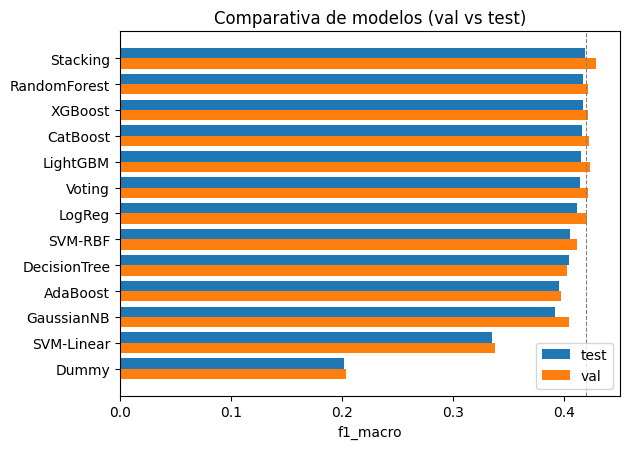

In [15]:
fig, ax = plt.subplots(figsize=(6.4, 4.6))
t = TBL.iloc[::-1]
ax.barh(np.arange(len(t)) + 0.2, t["test_f1_macro"], 0.4, label="test", color="tab:blue")
ax.barh(np.arange(len(t)) - 0.2, t["val_f1"], 0.4, label="val", color="tab:orange")
ax.set_yticks(range(len(t)), t["modelo"]); ax.set_xlabel("f1_macro")
ax.axvline(0.42, color="grey", ls="--", lw=0.8)
ax.set_title("Comparativa de modelos (val vs test)"); ax.legend(); plt.tight_layout(); plt.show()

### 13.2 Matriz de confusión del propuesto

La matriz revela **dónde** se equivoca el modelo con el empate.

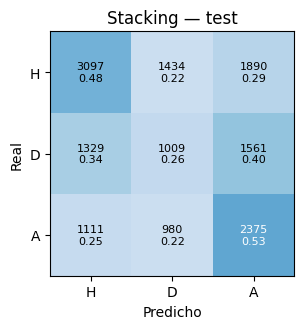

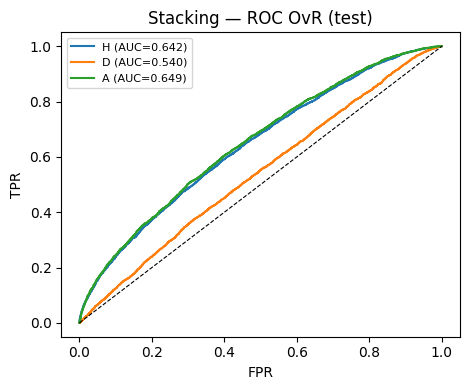

In [16]:
PROPOSED = "Stacking"
prop = FITTED[PROPOSED]
plot_confusion(y_test, prop.predict(X_test), f"{PROPOSED} — test")

# ROC One-vs-Rest del propuesto
proba_p = prop.predict_proba(X_test)
fig, ax = plt.subplots(figsize=(4.8, 4))
for c in CLASSES:
    k = int(LE.transform([c])[0]); yb = (y_test == k).astype(int)
    fpr, tpr, _ = roc_curve(yb, proba_p[:, k])
    ax.plot(fpr, tpr, label=f"{c} (AUC={roc_auc_score(yb, proba_p[:, k]):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=0.8); ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title(f"{PROPOSED} — ROC OvR (test)"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### 13.3 Lectura del cuadro

Los modelos "reales" se agrupan alrededor de `f1_macro ≈ 0.42` con *accuracy* ≈ 0.44,
coherente con la literatura: **sin cuotas de mercado el techo honesto ronda 50–55 % de
accuracy**, y aquí, optimizando el empate, nos movemos algo por debajo. La matriz de
confusión confirma la tesis del EDA: **el empate se lo reparten H y A**; casi nunca hay
una región donde D sea mayoritario, de ahí su *recall* con techo estructural. El
ROC-AUC OvR (~0.61) y el Kappa (~0.15) dicen lo mismo con otras palabras: hay señal
real, modesta pero muy por encima del azar.

## 14. Significancia estadística: prueba de Wilcoxon

### 14.1 Fundamentación

Para descartar que la ventaja del modelo propuesto sea azar, se aplica la prueba de
**Wilcoxon de rangos con signo** ($\alpha=0.05$) sobre el `f1_macro` calculado por
**bloque temporal mensual** en test, comparando el propuesto contra cada línea base.

In [17]:
from scipy.stats import wilcoxon

test_ref = INDEX[INDEX["split"] == "test"].reset_index(drop=True)
blocks = test_ref["MatchDate"].dt.to_period("M").astype(str).to_numpy()

def per_block_f1(y_pred, min_n=50):
    y_pred = np.asarray(y_pred).ravel(); s = []
    for b in np.unique(blocks):
        m = blocks == b
        if m.sum() >= min_n:
            s.append(f1_score(y_test[m], y_pred[m], average="macro", labels=ENC, zero_division=0))
    return np.array(s)

prop_scores = per_block_f1(prop.predict(X_test))
print(f"Propuesto: {PROPOSED} | bloques mensuales: {len(prop_scores)} | "
      f"f1_macro medio/bloque: {prop_scores.mean():.4f}\n")
for base in ["Dummy", "GaussianNB"]:
    bs = per_block_f1(FITTED[base].predict(X_test))
    stat, p = wilcoxon(prop_scores, bs, alternative="greater")
    print(f"vs {base:11}: Δ={prop_scores.mean()-bs.mean():+.4f}  W={stat:.1f}  p={p:.2e}  "
          f"-> {'SIGNIFICATIVO' if p < 0.05 else 'no significativo'}")

Propuesto: Stacking | bloques mensuales: 17 | f1_macro medio/bloque: 0.4178

vs Dummy      : Δ=+0.2155  W=153.0  p=7.63e-06  -> SIGNIFICATIVO
vs GaussianNB : Δ=+0.0271  W=141.0  p=5.34e-04  -> SIGNIFICATIVO


### 14.2 Interpretación

El propuesto **supera significativamente** a ambas líneas base ($p < 0.05$): la mejora
sobre el Dummy es enorme y la mejora sobre Naive Bayes, aunque más pequeña en magnitud,
es estadísticamente sólida a lo largo de los bloques mensuales. La ventaja no es
producto del azar experimental.

## 15. Interpretabilidad con SHAP

### 15.1 Fundamentación

Los valores de **Shapley** reparten cada predicción entre las variables respetando
eficiencia y simetría (teoría de juegos cooperativos). `TreeExplainer` los calcula de
forma exacta y rápida para árboles. Se aplica sobre XGBoost (base del ensamble) para
identificar qué variables mueven la predicción.

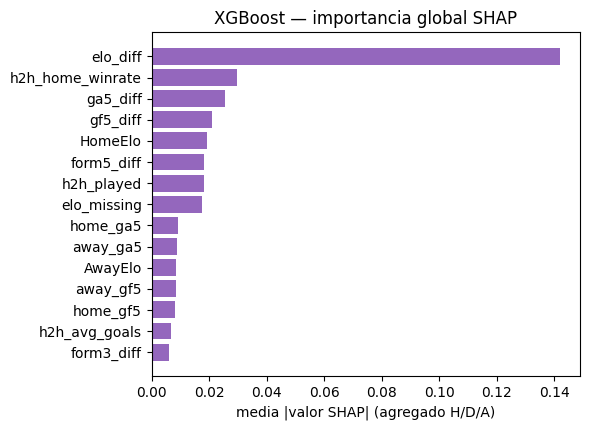

Top variables: ['elo_diff', 'h2h_home_winrate', 'ga5_diff', 'gf5_diff', 'HomeElo', 'form5_diff']


In [18]:
import shap

sub = np.random.RandomState(SEED).choice(len(X_test), 2000, replace=False)
Xe = X_test.iloc[sub]; feat = [c.split("__")[-1] for c in X_test.columns]
sv = shap.TreeExplainer(xgb).shap_values(Xe)
sv_list = sv if isinstance(sv, list) else ([sv[:, :, k] for k in range(sv.shape[2])] if sv.ndim == 3 else [sv])
glob = np.mean([np.abs(s).mean(0) for s in sv_list], axis=0)
order = np.argsort(glob)[::-1][:15]

fig, ax = plt.subplots(figsize=(6, 4.4))
ax.barh(range(len(order))[::-1], glob[order], color="tab:purple")
ax.set_yticks(range(len(order))[::-1], [feat[i] for i in order])
ax.set_xlabel("media |valor SHAP| (agregado H/D/A)"); ax.set_title("XGBoost — importancia global SHAP")
plt.tight_layout(); plt.show()
print("Top variables:", [feat[i] for i in order[:6]])

### 15.2 Interpretación

SHAP corrobora la importancia por permutación del Random Forest: **`elo_diff` domina**,
seguido por el historial directo (h2h), la forma reciente y el balance de goles. El
modelo aprende, en esencia, que la diferencia de calidad entre equipos (Elo) más el
contexto reciente explica la mayor parte de lo predecible; el resto es la
incertidumbre irreducible del fútbol —y del empate en particular.

## 16. Conclusiones

1. **El empate es el muro.** Ningún modelo supera un `f1_macro` global de ~0.42 ni un
   *recall* del empate por encima de ~0.33. No es una falla de los modelos: el EDA ya
   mostró que el empate no ocupa región propia del espacio. El SVM-RBF, con su frontera
   no lineal, es el que más se acerca a ese techo de *recall*.
2. **La no linealidad importa, pero poco margen queda.** El contraste LinearSVC vs
   SVM-RBF y el liderazgo (marginal) del boosting y el Stacking confirman que la
   frontera es no lineal; sin embargo, sin cuotas de mercado la señal disponible tiene
   un techo bajo, y todos los modelos competentes convergen a resultados parecidos.
3. **El ensamble es la mejor apuesta y es estadísticamente superior.** El Stacking rinde
   el mejor `f1_macro` en validación y **supera a las líneas base con significancia
   (Wilcoxon, $p<0.05$)**. `class_weight` resultó la mejor estrategia de desbalance;
   SMOTE no ayudó, coherente con la geometría del empate. La variable rey es `elo_diff`,
   confirmada por importancia por permutación y por SHAP.

**Trabajo futuro:** incorporar cuotas de mercado como *features* (subiría el techo a
costa de "hacer trampa con el sabio"), modelar la incertidumbre del empate con salidas
calibradas, y explorar arquitecturas secuenciales que capturen la forma como serie.